In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json
with open("/content/drive/MyDrive/Haystack/manual.json", "r", encoding="utf-8") as file:
  manual=json.load(file)

# save the contexts, titles and pages for later use
contexts = [document["context"] for document in manual]
titles = [document["title"] for document in manual]
pages = [document["page"] for document in manual]

with open("/content/drive/MyDrive/Haystack/LDS_current_scores.json", "r", encoding="utf-8") as file:
  LDS_current_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/LDS_rewritten_scores.json", "r", encoding="utf-8") as file:
  LDS_rewritten_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/LDS_rewritten_queries.json", "r", encoding="utf-8") as file:
  LDS_rewritten_queries=json.load(file)
with open("/content/drive/MyDrive/Haystack/manual_QAs.json", "r", encoding="utf-8") as qas_file:
  manual_QAs = json.load(qas_file)

LDS_current_queries = [conversation["Queries"] for conversation in manual_QAs["LDS"]]

with open("/content/drive/MyDrive/Haystack/LDS_queries_difference.json", "r", encoding="utf-8") as file:
  LDS_info_hiding_rate=json.load(file)

with open("/content/drive/MyDrive/Haystack/LDS_rewritten_keywords_scores.json", "r", encoding='utf-8') as file:
  LDS_rewritten_keywords_scores=json.load(file)

Mounted at /content/drive


In [6]:
LDS_keywords_mean_scores = [sum(score[:5])/5 for scores in LDS_rewritten_keywords_scores for score in scores]
LDS_rewritten_mean_scores = [sum(score[:5])/5 for scores in LDS_rewritten_scores for score in scores]
LDS_rates = [rate for rates in LDS_info_hiding_rate for rate in rates]

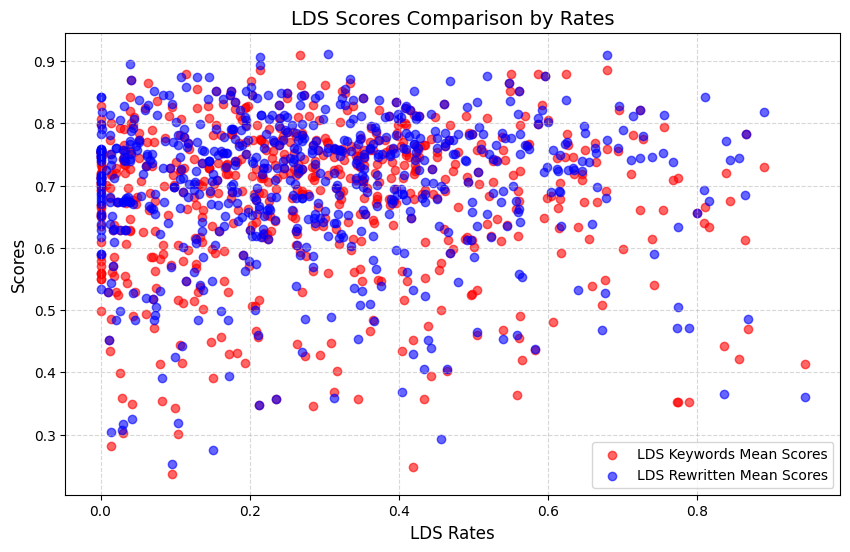

In [8]:
import matplotlib.pyplot as plt

# 假设你的数据如下（请替换为你实际的 list 变量）
# LDS_rates = [...]
# LDS_keywords_mean_scores = [...]
# LDS_rewritten_mean_scores = [...]

def plot_lds_scores(rates, keywords_scores, rewritten_scores):
    plt.figure(figsize=(10, 6))

    # 1. 绘制红色散点 (Keywords Mean Scores)
    plt.scatter(rates, keywords_scores, color='red', label='LDS Keywords Mean Scores', alpha=0.6)

    # 2. 绘制蓝色散点 (Rewritten Mean Scores)
    plt.scatter(rates, rewritten_scores, color='blue', label='LDS Rewritten Mean Scores', alpha=0.6)

    # 设置图表属性
    plt.title('LDS Scores Comparison by Rates', fontsize=14)
    plt.xlabel('LDS Rates', fontsize=12)
    plt.ylabel('Scores', fontsize=12)

    # 添加图例，方便区分红色和蓝色
    plt.legend()

    # 添加网格线，方便观察数值
    plt.grid(True, linestyle='--', alpha=0.5)

    # 显示图表
    plt.show()

# 调用函数
plot_lds_scores(LDS_rates, LDS_keywords_mean_scores, LDS_rewritten_mean_scores)

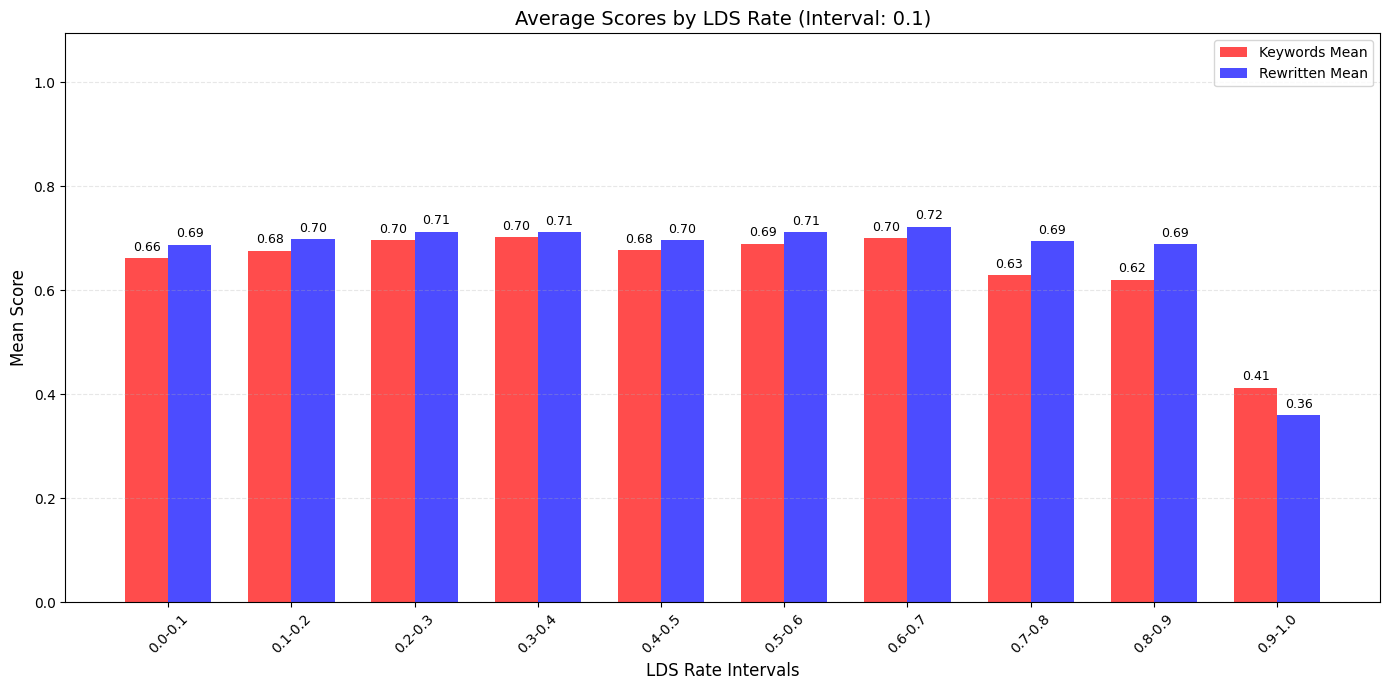

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_detailed_binned_scores(rates, keywords, rewritten):
    # 1. 构造数据
    df = pd.DataFrame({
        'rate': rates,
        'keywords': keywords,
        'rewritten': rewritten
    })

    # 2. 自动生成区间 (Bins)
    # 生成 [0.0, 0.1, 0.2, ..., 0.9, 1.0]
    bin_edges = np.arange(0, 1.1, 0.1)
    # 生成标签 ['0-0.1', '0.1-0.2', ..., '0.9-1.0']
    labels = [f'{round(bin_edges[i],1)}-{round(bin_edges[i+1],1)}' for i in range(len(bin_edges)-1)]

    # 3. 分箱并计算平均值
    df['bin'] = pd.cut(df['rate'], bins=bin_edges, labels=labels, include_lowest=True)
    # 计算每个区间的均值
    binned_avg = df.groupby('bin', observed=True).mean()

    # 4. 绘图
    plt.figure(figsize=(14, 7)) # 增加宽度以适应更多标签

    x = np.arange(len(binned_avg))
    width = 0.35

    # 绘制对比柱状图
    rects1 = plt.bar(x - width/2, binned_avg['keywords'], width, label='Keywords Mean', color='red', alpha=0.7)
    rects2 = plt.bar(x + width/2, binned_avg['rewritten'], width, label='Rewritten Mean', color='blue', alpha=0.7)

    # 5. 添加数值标注 (在柱子顶部显示具体分数)
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            plt.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3点垂直偏移
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    autolabel(rects1)
    autolabel(rects2)

    # 图表修饰
    plt.title('Average Scores by LDS Rate (Interval: 0.1)', fontsize=14)
    plt.xlabel('LDS Rate Intervals', fontsize=12)
    plt.ylabel('Mean Score', fontsize=12)
    plt.xticks(x, binned_avg.index, rotation=45) # 标签倾斜45度防止重叠
    plt.ylim(0, max(df['keywords'].max(), df['rewritten'].max()) * 1.2) # 自动调整y轴高度
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout() # 自动调整布局，防止标签被切掉
    plt.show()

# 调用
plot_detailed_binned_scores(LDS_rates, LDS_keywords_mean_scores, LDS_rewritten_mean_scores)